# Training for lead time 1

## Imports

In [2]:
from tensorflow.keras import layers, models                                             # type: ignore
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from tensorflow.keras.optimizers import Adam                                            # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore

In [3]:
lead_time = 3

In [23]:
resolution = 11

## Read data

In [24]:
raw_test_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-test-Dakar-feature.csv", index_col=None)
test_data_y= pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-test-Dakar-target-lt1.csv", header=None)

In [25]:
raw_train_X_part1 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-feature-part1.csv")
raw_train_X_part2 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-feature-part2.csv")
raw_train_X_part3 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-feature-part3.csv")
raw_train_X_part4 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-feature-part4.csv")

train_data_y_part1 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-target-part1-lt{lead_time}.csv", header=None)
train_data_y_part2 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-target-part2-lt{lead_time}.csv", header=None)
train_data_y_part3 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-target-part3-lt{lead_time}.csv", header=None)
train_data_y_part4 = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/dataset/map/{resolution}x{resolution}/full-map-train-Dakar-target-part4-lt{lead_time}.csv", header=None)

In [26]:
raw_train_data_X = pd.concat([raw_train_X_part2, raw_train_X_part3, raw_train_X_part4])
train_data_y = pd.concat([train_data_y_part2, train_data_y_part3, train_data_y_part4])

In [27]:
raw_train_data_X.shape

(69265, 30)

In [28]:
train_data_y.shape

(69265, 121)

In [29]:
def select(df):
    selection_index_lat = df["lat5"] < 30
    selection_index_lon = df["lon5"] < 30
    selection_index = selection_index_lat * selection_index_lon
    return selection_index

index_train = select(raw_train_data_X)
index_test = select(raw_test_data_X)

raw_train_data_X = raw_train_data_X[index_train]
raw_test_data_X = raw_test_data_X[index_test]

train_data_y = train_data_y[index_train]
test_data_y = test_data_y[index_test]

In [30]:
raw_train_data_X.to_csv(f"train-data-Dakar-map-features.csv", index=False)
train_data_y.to_csv(f"train-data-Dakar-map-target-lt{lead_time}.csv", index=False)

raw_test_data_X.to_csv(f"test-data-Dakar-map-features.csv", index=False)
test_data_y.to_csv(f"test-data-Dakar-map-target-lt{lead_time}.csv", index=False)


In [347]:
index_train.shape

(69265,)

In [348]:
raw_train_X, raw_validation_X, train_y, validation_y = train_test_split(raw_train_data_X, train_data_y, test_size=0.3, random_state=12)

In [349]:
variable = "lon"
for i in range(5):
    print(np.min(raw_train_data_X[f"{variable}{i+1}"]), np.max(raw_train_data_X[f"{variable}{i+1}"]))

-17.97 -10.02
-17.97 -10.02
-17.97 -5.0
-17.97 -5.0
-17.97 -5.0


## Preprocessing

In [350]:
t0 = "year,month,day,hour,minute,"
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"
features = t0 + location + wavelet_power + storm_size + distance
field =  features
field = field.split(',')

In [351]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [352]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [353]:
to_scale = wavelet_power + storm_size + distance

In [354]:
def prepare(df):
    df = log_transform(df, to_scale.split(',')[:-1])
    df = sqrt_transform(df, t0.split(',')[:-1])
    return df

### Transforming

In [355]:
transform = True

if transform:
    train_X = prepare(raw_train_X)
    validation_X = prepare(raw_validation_X)
    test_X = prepare(raw_test_data_X)
else:
    train_X = raw_train_X
    validation_X = raw_validation_X
    test_X = raw_test_data_X

### Scaling

In [356]:
scaler = StandardScaler()
std_X_train = scaler.fit_transform(train_X)
std_X_val = scaler.transform(validation_X)
std_X_test = scaler.transform(test_X)

## Class Weights

In [357]:
n_train = train_y.shape[0]
n_validation = validation_y.shape[0]

In [358]:
train_y = train_y.to_numpy().reshape(n_train, resolution, resolution)
validation_y = validation_y.to_numpy().reshape(n_validation, resolution, resolution)

In [359]:
num_pos = np.sum(train_y.flatten())
num_neg = train_y.flatten().shape[0]- num_pos

In [360]:
pos_weight = num_neg / (num_pos)

In [361]:
pos_weight

7.260200538608763

In [362]:
def weighted_binary_crossentropy(y_true, y_pred, pos_weight=1.0, neg_weight=1.0):
    """
    Custom weighted binary cross-entropy loss function.

    Parameters:
    y_true: tensor of true labels (0 or 1)
    y_pred: tensor of predicted probabilities
    pos_weight: weight for the positive class (default=1.0)
    neg_weight: weight for the negative class (default=1.0)

    Returns:
    loss: computed weighted binary cross-entropy loss
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    loss = - (pos_weight * y_true * tf.math.log(y_pred + tf.keras.backend.epsilon()) + 
              neg_weight * (1 - y_true) * tf.math.log(1 - y_pred + tf.keras.backend.epsilon()))
    
    return tf.reduce_mean(loss)

### Creating the model 

In [6]:
30 * 32 + 32 * 121 + 32*9+ 9 + 32 + 121

5282

In [363]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(30,)), 
  tf.keras.layers.Dense(32, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Dense(resolution * resolution, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Reshape((resolution, resolution, 1)),
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer=he_normal()),
  tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same', kernel_initializer=he_normal()),
  tf.keras.layers.Reshape((resolution, resolution)),
])

In [364]:
def stable_binary_crossentropy(y_true, y_pred):
    epsilon = 1e-7
    y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
    return tf.keras.losses.binary_crossentropy(y_true, y_pred)

In [365]:
cl_thresholds = 0.15

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]

In [366]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_prc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)

In [367]:
l1_reg = tf.keras.regularizers.L1(0.1)
for layer in model.layers[:]:  # Skip the first layer (usually input)
  # Apply the regularizer to the kernel (weights) of the current layer
  layer.kernel_regularizer = l1_reg

In [368]:
optimizer = Adam(clipvalue=1.0, learning_rate=1e-3)
model.compile(optimizer=optimizer, 
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[tf.keras.metrics.AUC(name='prc', curve='PR')])

In [369]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 121)            │         3,993 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_14 (Reshape)            │ (None, 11, 11, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 11, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 11, 11, 1)      │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_15 (Reshape)            │ (None, 11, 11)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,338 (20.85 KB)

 Trainable params: 5,338 (20.85 KB)

 Non-trainable params: 0 (0.00 B)

In [370]:
model_history = model.fit(std_X_train, 
                          train_y, 
                          epochs=500,                           
                          batch_size = 1024,         
                          callbacks = [early_stopping],
                          validation_data=(std_X_val, validation_y)
                        )

Epoch 1/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.4532 - prc: 0.1300 - val_loss: 0.3644 - val_prc: 0.1952
Epoch 2/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.3496 - prc: 0.2115 - val_loss: 0.3391 - val_prc: 0.2373
Epoch 3/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.3282 - prc: 0.2487 - val_loss: 0.3298 - val_prc: 0.2540
Epoch 4/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.3262 - prc: 0.2616 - val_loss: 0.3250 - val_prc: 0.2658
Epoch 5/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.3218 - prc: 0.2764 - val_loss: 0.3218 - val_prc: 0.2744
Epoch 6/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.3161 - prc: 0.2828 - val_loss: 0.3197 - val_prc: 0.2804
Epoch 7/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.3172 - prc: 0.2904 - val_loss: 0.3182 - val_prc: 0.2859
Epoch 8/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.3098 - prc: 0.2937 - val_loss: 0.3170 - val_prc: 0.2903
Epoch 9/500
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - lo

In [371]:
n_test = test_data_y.shape[0]

In [372]:
train_y = train_y.reshape(train_y.shape[0], resolution, resolution)

In [373]:
test_y = test_data_y.to_numpy().reshape(n_test, resolution, resolution)

In [374]:
pred_y_train = model.predict(std_X_train).flatten()
pred_y_test = model.predict(std_X_test).flatten()

1512/1512 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
558/558 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [375]:
idx = []

for i in range(train_y.shape[0]):
    idx.append(np.mean(train_y[i]))


In [376]:
idx = []

for i in range(test_y.shape[0]):
    idx.append(np.mean(test_y[i]))


In [377]:
idx_max = np.argmax(idx)

In [378]:
test_y[idx_max]

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [379]:
raw_test_data_X.iloc[idx_max, :]

year       2020.00
month         9.00
day           6.00
hour          0.00
minute       15.00
lat1         13.57
lon1        -14.78
lat2         15.90
lon2        -17.25
lat3         13.48
lon3        -15.63
lat4         13.16
lon4        -15.05
lat5         14.02
lon5        -16.44
wp1       14430.00
wp2       12369.00
wp3       11801.00
wp4       13867.00
wp5        8758.00
size1      4800.00
size2      1475.00
size3     14525.00
size4       400.00
size5      3800.00
ds1          17.03
ds2          43.60
ds3          52.00
ds4          64.35
ds5          64.50
Name: 4449, dtype: float64

In [380]:
pred_y_test.reshape(n_test, resolution, resolution)[idx_max]

array([[0.61476153, 0.6106271 , 0.6206401 , 0.59455043, 0.5912396 ,
        0.47852454, 0.45957795, 0.2065075 , 0.17233811, 0.13886698,
        0.16160816],
       [0.58715534, 0.5772285 , 0.5891332 , 0.5728213 , 0.58542645,
        0.4817038 , 0.42688146, 0.22317924, 0.17011006, 0.15368852,
        0.15200593],
       [0.5936321 , 0.5851841 , 0.53872436, 0.5297977 , 0.576855  ,
        0.6543176 , 0.49753436, 0.35900146, 0.2195228 , 0.19027846,
        0.24589206],
       [0.57204384, 0.5405094 , 0.5185236 , 0.51271856, 0.547092  ,
        0.6347955 , 0.49231848, 0.32169184, 0.2249299 , 0.2126895 ,
        0.31937373],
       [0.50088966, 0.49226877, 0.487785  , 0.49788356, 0.53990304,
        0.636379  , 0.6566    , 0.40134144, 0.2926676 , 0.28535083,
        0.3940709 ],
       [0.47235397, 0.4851215 , 0.5454697 , 0.6091692 , 0.63569736,
        0.6269624 , 0.6042047 , 0.6359956 , 0.3252633 , 0.25658166,
        0.28419358],
       [0.48986012, 0.52078545, 0.62432194, 0.6099039 , 0.

## ROC

In [381]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [382]:
auc_train = roc_auc_score(train_y.flatten(), pred_y_train)
auc_test = roc_auc_score(test_y.flatten(), pred_y_test)

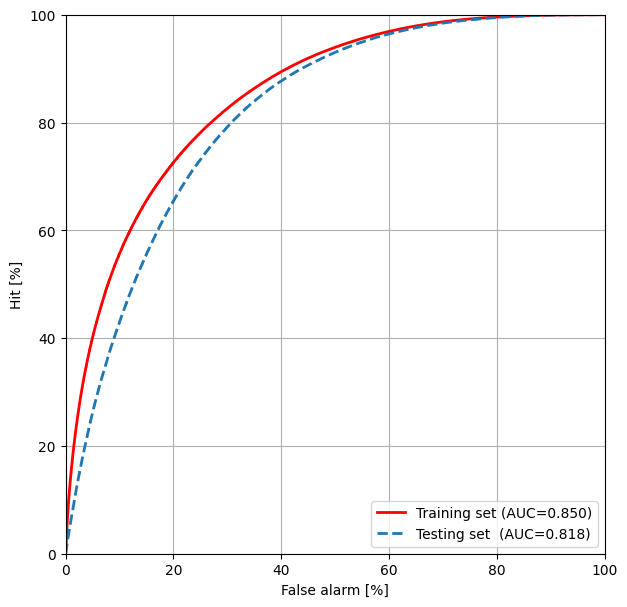

In [383]:
plot_roc(f"Training set (AUC={auc_train:.3f})", train_y.flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", test_y.flatten(), pred_y_test.flatten(), color=colors[0], linestyle='--')
plt.legend(loc='lower right');

## Reliability diagram

In [384]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

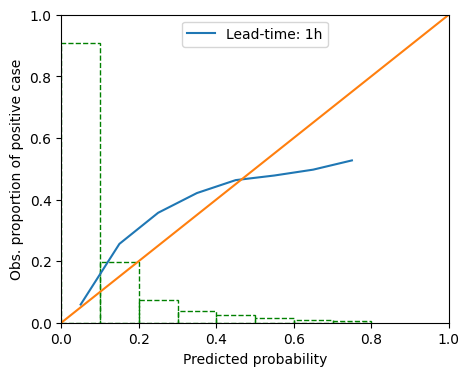

In [385]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(test_y.flatten(), pred_y_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"Lead-time: 1h")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

## Plotting

In [386]:
import cartopy.crs as ccrs                              # type: ignore
import cartopy.feature as cfeature                      # type: ignore
import warnings
warnings.filterwarnings("ignore")
from netCDF4 import Dataset                             # type: ignore

In [387]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [388]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")

xlimit = 1803
ylimit = 556

lons = geodata["lons_mid"][:ylimit, :xlimit]
lats = geodata["lats_mid"][:ylimit, :xlimit]

In [389]:
original_y_min, original_x_min = nflics.X0(13, -18)
original_y_max, original_x_max = nflics.X0(16, -15)

# To fix dimensions

y_min = original_y_min - 2
y_max = original_y_max + 2
x_min = original_x_min 
x_max = original_x_max + 1

In [390]:
def downsample_grid(grid, factor):
    # Ensure that the grid dimensions are divisible by the factor
    assert grid.shape[0] % factor == 0
    assert grid.shape[1] % factor == 0

    # Reshape the grid to factor blocks and then take the mean
    grid_downsampled = grid.reshape(grid.shape[0] // factor, factor,
                                    grid.shape[1] // factor, factor).mean(axis=(1, 3))
    
    return grid_downsampled

def create_lat_lon_grid(latitudes, longitudes, factor):
    lat_min = latitudes.min()
    lat_max = latitudes.max()
    lon_min = longitudes.min()
    lon_max = longitudes.max()
    
    num_rows = latitudes.shape[0] // factor
    num_cols = longitudes.shape[1] // factor
    
    new_lats = np.linspace(lat_min, lat_max, num_rows)
    new_lons = np.linspace(lon_min, lon_max, num_cols)
    
    new_latitudes, new_longitudes = np.meshgrid(new_lats, new_lons, indexing='ij')
    
    return new_latitudes, new_longitudes

In [391]:
if resolution == 11:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 10)
else:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 5)

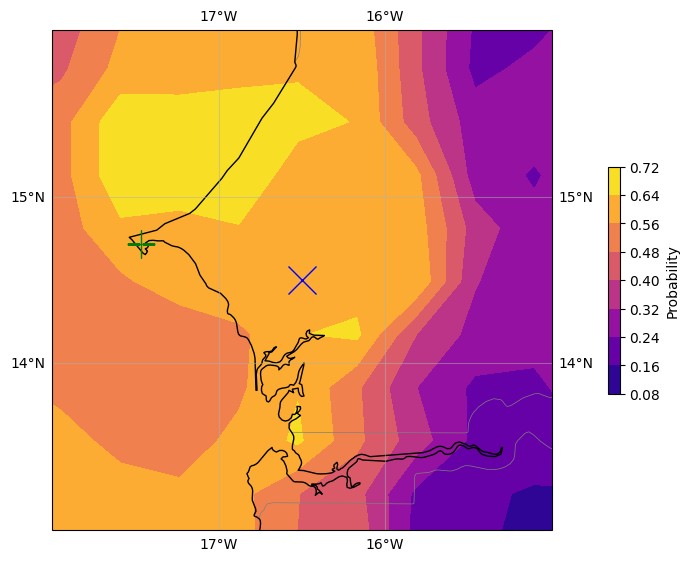

In [392]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

contour_core = ax.contourf(downsampled_lons, downsampled_lats, pred_y_test.reshape(n_test, resolution, resolution)[idx_max], transform=ccrs.PlateCarree(), cmap="plasma")
plt.colorbar(contour_core, label="Probability", fraction=0.02, pad=0.1)

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

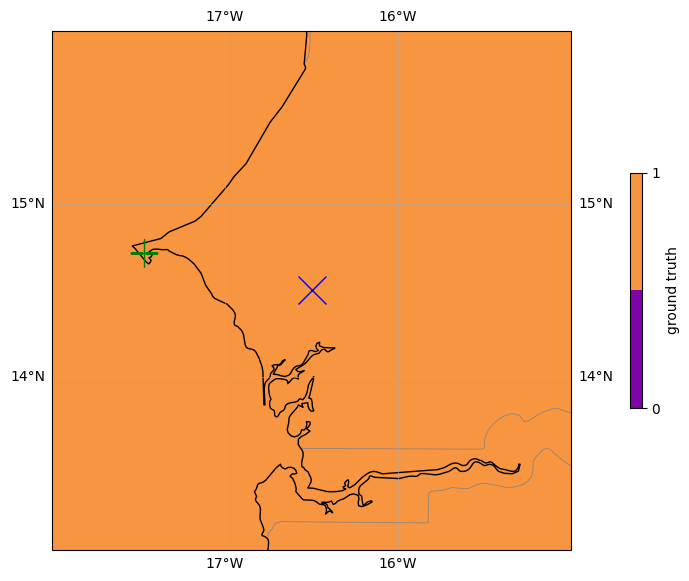

In [393]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

levels = [0, 0.5, 1]

contour_core = ax.contourf(downsampled_lons, downsampled_lats, test_y[idx_max], transform=ccrs.PlateCarree(), cmap="plasma", levels=levels)
cbar = plt.colorbar(contour_core, label="ground truth", fraction=0.02, pad=0.1)

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

In [396]:
#model.save(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/Dakar-map-t{lead_time}.keras')